In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the saved merged data
df = pd.read_csv('../data/processed/merged_data.csv')

print("Data loaded successfully!")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nTarget distribution:")
print(df['is_return'].value_counts())

Data loaded successfully!
Shape: (112163, 24)

Columns: ['order_id', 'customer_id', 'order_purchase_timestamp', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'is_return', 'order_item_id', 'product_id', 'seller_id', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'customer_unique_id', 'customer_state', 'review_score', 'seller_state']

Target distribution:
is_return
0    110840
1      1323
Name: count, dtype: int64


In [9]:
# Remove duplicates first
df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")

Shape after removing duplicates: (111767, 24)


In [10]:
# Convert all timestamp columns to datetime
timestamp_cols = [
    'order_purchase_timestamp',
    'order_delivered_carrier_date', 
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in timestamp_cols:
    df[col] = pd.to_datetime(df[col])
print("✅ Timestamps converted!")
print(df[timestamp_cols].dtypes)

✅ Timestamps converted!
order_purchase_timestamp         datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [11]:
df.head()

,order_id,customer_id,order_purchase_timestamp,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_return,order_item_id,product_id,seller_id,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_unique_id,customer_state,review_score,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,0,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,...,268.0,4.0,500.0,19.0,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,SP,4.0,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,0,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,...,178.0,1.0,400.0,19.0,13.0,19.0,af07308b275d755c9edb36a90c618231,BA,4.0,SP
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,0,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,...,232.0,1.0,420.0,24.0,19.0,21.0,3a653a41f6f9fc3d2a113cf8398680e8,GO,5.0,SP
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,0,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,...,468.0,3.0,450.0,30.0,10.0,20.0,7c142cf63193a1473d2e66489a9ae977,RN,5.0,MG
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,0,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,...,316.0,4.0,250.0,51.0,15.0,15.0,72632f0f9dd73dfee390c9b22eb56dd6,SP,5.0,SP


#### Feature Engneering

In [14]:
#Feature1 Delevary delay days
df['delivery_delay_days'] = (
    df['order_delivered_customer_date'] - 
    df['order_estimated_delivery_date']
).dt.days

#Feature2 is Delivary late
df['is_late_delivery'] = (df['delivery_delay_days'] > 0).astype(int)

#Feature3 Days to ship
df['days_to_ship'] = (
    df['order_delivered_carrier_date'] - 
    df['order_purchase_timestamp']
).dt.days

#Feature4 Days to Deliver
df['total_delivery_days'] = (
    df['order_delivered_customer_date'] - 
    df['order_purchase_timestamp']
).dt.days

print("Delivery features created!")
display(df[['delivery_delay_days', 'is_late_delivery', 
          'days_to_ship', 'total_delivery_days']].describe())
    

Delivery features created!


,delivery_delay_days,is_late_delivery,days_to_ship,total_delivery_days
count,110448.000000,111767.000000,110523.000000,110448.000000
mean,-12.029743,0.065118,2.796242,12.012042
std,10.159264,0.246734,3.666569,9.450678
min,-147.000000,0.000000,-172.000000,0.000000
25%,-17.000000,0.000000,1.000000,6.000000
50%,-13.000000,0.000000,2.000000,10.000000
75%,-7.000000,0.000000,4.000000,15.000000
max,188.000000,1.000000,125.000000,209.000000


In [18]:
#Feature 5  price to frighet ratio
df['freight_ratio'] = df['freight_value'] / (df['price'] + 1)

#Feature 6 Total Order Value
df['total_order_value'] = df['price'] + df['freight_value']

#Feature 7 Product Volume
df['product_volume_cm3'] = (
    df['product_length_cm'] * 
    df['product_height_cm'] * 
    df['product_width_cm']
)

#feature 8 price per gram
df['price_per_gram'] = df['price'] / (df['product_weight_g'] + 1)
print("Price & Product features created!")
print(df[['freight_ratio', 'total_order_value', 
          'product_volume_cm3', 'price_per_gram']].describe())

Price & Product features created!
       freight_ratio  total_order_value  product_volume_cm3  price_per_gram
count  110999.000000      110999.000000       110981.000000   110981.000000
mean        0.309006         140.131577        15182.263351        0.197178
std         0.299596         190.178720        23239.947637        1.161997
min         0.000000           6.080000          168.000000        0.000765
25%         0.133135          55.130000         2850.000000        0.043909
50%         0.228314          92.110000         6460.000000        0.089095
75%         0.383495         157.600000        18150.000000        0.198609
max        12.054054        6929.310000       296208.000000      129.900000


In [21]:
#Feature 9 Customer order count (how many orders this customer made)
customer_order_counts = df.groupby(
    'customer_unique_id')['order_id'].count().reset_index()
customer_order_counts.columns = ['customer_unique_id', 'customer_order_count']
df = df.merge(customer_order_counts, on='customer_unique_id', how='left')

#Feature 10 Is repeat customer?
df['is_repeat_customer'] = (df['customer_order_count'] > 1).astype(int)

#Feature 11 Seller total orders
seller_order_counts = df.groupby(
    'seller_id')['order_id'].count().reset_index()
seller_order_counts.columns = ['seller_id', 'seller_total_orders']
df = df.merge(seller_order_counts, on='seller_id', how='left')

#Feature 12 Seller average review score
seller_reviews = df.groupby(
    'seller_id')['review_score'].mean().reset_index()
seller_reviews.columns = ['seller_id', 'seller_avg_review_score']
df = df.merge(seller_reviews, on='seller_id', how='left')

print("Customer & Seller features created!")
print(df[['customer_order_count', 'is_repeat_customer',
          'seller_total_orders', 'seller_avg_review_score']].describe())

Customer & Seller features created!
       customer_order_count  is_repeat_customer  seller_total_orders  \
count         111767.000000       111767.000000        110999.000000   
mean               1.523088            0.260104           424.388445   
std                1.377849            0.438693           559.291370   
min                1.000000            0.000000             1.000000   
25%                1.000000            0.000000            56.000000   
50%                1.000000            0.000000           172.000000   
75%                2.000000            1.000000           525.000000   
max               24.000000            1.000000          2007.000000   

       seller_avg_review_score  
count            110994.000000  
mean                  4.067610  
std                   0.380434  
min                   1.000000  
25%                   3.902715  
50%                   4.102041  
75%                   4.268657  
max                   5.000000  


In [22]:
# Feature 13: Purchase month
df['purchase_month'] = df['order_purchase_timestamp'].dt.month

# Feature 14: Purchase day of week (0=Monday, 6=Sunday)
df['purchase_dayofweek'] = df['order_purchase_timestamp'].dt.dayofweek

# Feature 15: Is weekend purchase?
df['is_weekend_purchase'] = (df['purchase_dayofweek'] >= 5).astype(int)

# Feature 16: Purchase hour
df['purchase_hour'] = df['order_purchase_timestamp'].dt.hour

print("✅ Timing features created!")
print(df[['purchase_month', 'purchase_dayofweek', 
          'is_weekend_purchase', 'purchase_hour']].describe())

✅ Timing features created!
       purchase_month  purchase_dayofweek  is_weekend_purchase  purchase_hour
count   111767.000000       111767.000000        111767.000000  111767.000000
mean         6.033972            2.744835             0.226659      14.746186
std          3.232958            1.962745             0.418672       5.314395
min          1.000000            0.000000             0.000000       0.000000
25%          3.000000            1.000000             0.000000      11.000000
50%          6.000000            3.000000             0.000000      15.000000
75%          8.000000            4.000000             0.000000      19.000000
max         12.000000            6.000000             1.000000      23.000000


In [23]:
df.shape

(111767, 43)

In [31]:
# Fill numerical missing values with median
numerical_cols = [
    'delivery_delay_days', 'days_to_ship', 'total_delivery_days',
    'freight_ratio', 'total_order_value', 'product_volume_cm3',
    'price_per_gram', 'review_score', 'product_weight_g',
    'product_length_cm', 'product_height_cm', 'product_width_cm',
    'product_name_lenght', 'product_description_lenght', 'product_photos_qty',
    'seller_avg_review_score', 'price', 'freight_value'
]

for col in numerical_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

# Fill categorical missing values with mode
df['product_category_name'] = df['product_category_name'].fillna(
    df['product_category_name'].mode()[0])
df['customer_state'] = df['customer_state'].fillna(
    df['customer_state'].mode()[0])
df['seller_state'] = df['seller_state'].fillna(
    df['seller_state'].mode()[0])

print("✅ Missing values handled!")
print("Remaining nulls:")
print(df.isnull().sum()[df.isnull().sum() > 0])

✅ Missing values handled!
Remaining nulls:
order_delivered_carrier_date     1244
order_delivered_customer_date    1319
order_item_id                     768
product_id                        768
seller_id                         768
seller_total_orders               768
dtype: int64


In [37]:
# Frequency encode product_category_name
category_freq = df['product_category_name'].value_counts() / len(df)
df['category_freq_encoded'] = df['product_category_name'].map(category_freq)
# Frequency encode customer_state
state_freq = df['customer_state'].value_counts() / len(df)
df['customer_state_encoded'] = df['customer_state'].map(state_freq)

# Frequency encode seller_state
seller_state_freq = df['seller_state'].value_counts() / len(df)
df['seller_state_encoded'] = df['seller_state'].map(seller_state_freq)

print("✅ Categorical features encoded!")
print(df[['category_freq_encoded', 
          'customer_state_encoded',
          'seller_state_encoded']].describe())

✅ Categorical features encoded!
       category_freq_encoded  customer_state_encoded  seller_state_encoded
count          111767.000000           111767.000000         111767.000000
mean                0.055111                0.218907              0.527302
std                 0.034379                0.177746              0.298581
min                 0.000018                0.000421              0.000027
25%                 0.030080                0.051249              0.077626
50%                 0.052663                0.128356              0.715408
75%                 0.076006                0.422397              0.715408
max                 0.119543                0.422397              0.715408


In [38]:
# Final feature list - drop ID columns and raw columns
cols_to_drop = [
    'order_id', 'customer_id', 'customer_unique_id',
    'product_id', 'seller_id', 'order_item_id',
    'order_purchase_timestamp', 'order_delivered_carrier_date',
    'order_delivered_customer_date', 'order_estimated_delivery_date',
    'product_category_name', 'customer_state', 'seller_state'
]

df_final = df.drop(columns=cols_to_drop)

print("✅ Final dataset ready!")
print("Shape:", df_final.shape)
print("\nFinal columns:", df_final.columns.tolist())
print("\nAny nulls remaining?", df_final.isnull().sum().sum())

✅ Final dataset ready!
Shape: (111767, 33)

Final columns: ['is_return', 'price', 'freight_value', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'review_score', 'delivery_delay_days', 'is_late_delivary', 'total_delivery_days', 'is_late_delivery', 'days_to_ship', 'freight_ratio', 'total_order_value', 'product_volume_cm3', 'price_per_gram', 'customer_order_count_x', 'is_repeat_customer', 'customer_order_count_y', 'customer_order_count', 'seller_total_orders', 'seller_avg_review_score', 'purchase_month', 'purchase_dayofweek', 'is_weekend_purchase', 'purchase_hour', 'category_freq_encoded', 'customer_state_encoded', 'seller_state_encoded']

Any nulls remaining? 768


In [39]:
# Fix all duplicates and nulls
df_final = df_final.drop(columns=[
    'is_late_delivary',           # typo duplicate
    'customer_order_count_x',     # merge duplicate
    'customer_order_count_y',     # merge duplicate
])

# Drop rows with remaining nulls (only 768 out of 111,767 = 0.6%)
df_final = df_final.dropna()

print("✅ Cleaned!")
print("Shape:", df_final.shape)
print("Columns:", df_final.columns.tolist())
print("Nulls remaining:", df_final.isnull().sum().sum())

✅ Cleaned!
Shape: (110999, 30)
Columns: ['is_return', 'price', 'freight_value', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'review_score', 'delivery_delay_days', 'total_delivery_days', 'is_late_delivery', 'days_to_ship', 'freight_ratio', 'total_order_value', 'product_volume_cm3', 'price_per_gram', 'is_repeat_customer', 'customer_order_count', 'seller_total_orders', 'seller_avg_review_score', 'purchase_month', 'purchase_dayofweek', 'is_weekend_purchase', 'purchase_hour', 'category_freq_encoded', 'customer_state_encoded', 'seller_state_encoded']
Nulls remaining: 0


In [40]:
# Save final processed dataset
df_final.to_csv('../data/processed/processed_data.csv', index=False)
print("✅ Final processed data saved!")
print("Shape saved:", df_final.shape)
print("\nFeature Summary:")
print(f"Total features: {df_final.shape[1] - 1}")  # minus target
print(f"Target column: is_return")
print(f"Class distribution:")
print(df_final['is_return'].value_counts())
print(f"\nReturn rate: {df_final['is_return'].mean()*100:.2f}%")

✅ Final processed data saved!
Shape saved: (110999, 30)

Feature Summary:
Total features: 29
Target column: is_return
Class distribution:
is_return
0    110449
1       550
Name: count, dtype: int64

Return rate: 0.50%


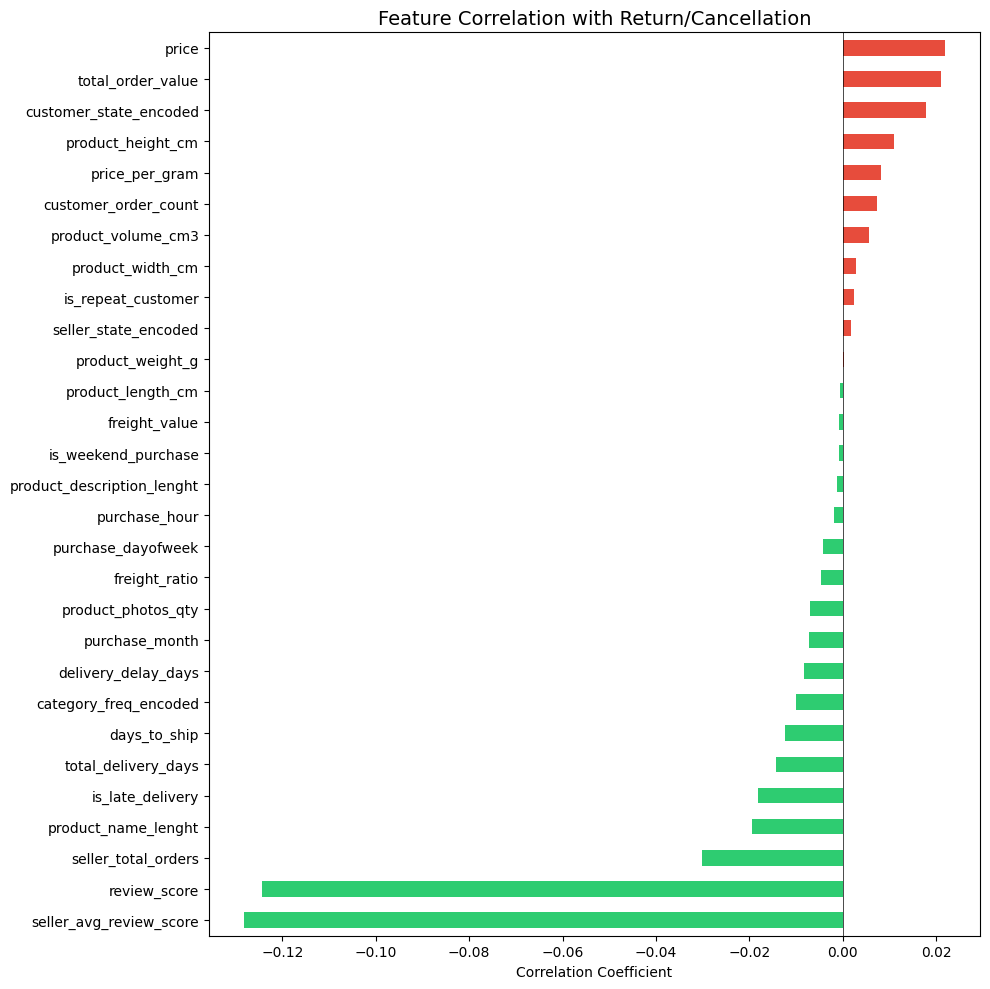

Plot saved!


In [41]:
# Correlation of all features with target
correlations = df_final.corr()['is_return'].drop('is_return').sort_values()

plt.figure(figsize=(10, 10))
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in correlations]
correlations.plot(kind='barh', color=colors)
plt.title('Feature Correlation with Return/Cancellation', fontsize=14)
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.savefig('../data/processed/feature_correlations.png')
plt.show()
print("Plot saved!")

In [42]:
# Reload processed data fresh
df_final = df.drop(columns=[
    'order_id', 'customer_id', 'customer_unique_id',
    'product_id', 'seller_id', 'order_item_id',
    'order_purchase_timestamp', 'order_delivered_carrier_date',
    'order_delivered_customer_date', 'order_estimated_delivery_date',
    'product_category_name', 'customer_state', 'seller_state',
    'is_late_delivary', 'customer_order_count_x', 'customer_order_count_y'
])

# Fill nulls with median instead of dropping rows!
for col in df_final.select_dtypes(include=[np.number]).columns:
    df_final[col] = df_final[col].fillna(df_final[col].median())

print("✅ Fixed!")
print("Shape:", df_final.shape)
print("\nClass distribution:")
print(df_final['is_return'].value_counts())
print(f"\nReturn rate: {df_final['is_return'].mean()*100:.2f}%")
print("Nulls remaining:", df_final.isnull().sum().sum())

✅ Fixed!
Shape: (111767, 30)

Class distribution:
is_return
0    110449
1      1318
Name: count, dtype: int64

Return rate: 1.18%
Nulls remaining: 0


In [43]:
# Save corrected final dataset
df_final.to_csv('../data/processed/processed_data.csv', index=False)
print("✅ Corrected processed data saved!")
print("Shape:", df_final.shape)

✅ Corrected processed data saved!
Shape: (111767, 30)


## 🔧 Feature Engineering Summary

**29 features created from raw data:**

### Delivery Features
- `delivery_delay_days` — actual vs estimated delivery gap
- `is_late_delivery` — binary flag for late deliveries
- `days_to_ship` — time from purchase to carrier pickup
- `total_delivery_days` — total time from purchase to customer

### Price & Product Features
- `freight_ratio` — freight cost relative to price
- `total_order_value` — price + freight combined
- `product_volume_cm3` — physical size of product
- `price_per_gram` — price density proxy

### Customer & Seller Features
- `customer_order_count` — loyalty indicator
- `is_repeat_customer` — binary loyalty flag
- `seller_total_orders` — seller experience
- `seller_avg_review_score` — seller quality score

### Timing Features
- `purchase_month`, `purchase_dayofweek`
- `is_weekend_purchase`, `purchase_hour`

### Encoded Features
- `category_freq_encoded` — product category frequency
- `customer_state_encoded` — customer location frequency
- `seller_state_encoded` — seller location frequency

### Key Insight from Correlation Plot
- `seller_avg_review_score` and `review_score` are 
  the STRONGEST negative predictors — bad reviews = more returns
- `price` and `total_order_value` are strongest 
  positive predictors — expensive items = more returns
- `seller_total_orders` — experienced sellers have fewer returns